# Forecasting using RNN networks

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random 
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from keras.models import Sequential
from keras.layers import GRU, Dropout, SimpleRNN, Dense, LSTM
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau 

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## Prepare Data

In [2]:
data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitcoin_data.csv", index_col=0)

In [3]:
# Set index to datetime 
data.index = pd.to_datetime(data.index)
 
isinstance(data.index, pd.DatetimeIndex)

True

In [4]:
# Normalize the data 
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

In [5]:
def create_sequences(data, window_size, target_col_idx):
    """
    data: NumPy array with all features (open, high, low, close)
    window_size: Number of past time steps to use
    target_col_idx: Index of the column to predict (close price = -1)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])  # Take all columns as input
        y.append(data[i + window_size, target_col_idx])  # Only the close price as output
    return np.array(X), np.array(y)

window_size = 15

target_col_idx = data.columns.get_loc("close")
X, y = create_sequences(data_normalized, window_size, target_col_idx=target_col_idx)
X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))  # Keep all features

### Split

In [6]:
split = int(len(X) * 0.8)  # 80% training, 20% testing
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (47062, 15, 4)
y_train shape: (47062,)
X_test shape: (11766, 15, 4)
y_test shape: (11766,)


## Implementing GRU

/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 15, 30)         │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 30)             │         5,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,851 (34.57 KB)

 Trainable params: 8,851 (34.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0224 - val_loss: 6.2019e-04
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0028 - val_loss: 5.3033e-04
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0020 - val_loss: 4.5867e-04
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0016 - val_loss: 0.0011
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0014 - val_loss: 9.1981e-04
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0013 - val_loss: 7.6779e-04
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0012 - val_loss: 0.0017
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0011 - val_loss: 0.0016
Epoch 9/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0010 - val_loss: 0.0015
Epoch 10/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.5958e-04 - val_loss: 0.0015
Epoch 11/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.4827e-04 - val_loss: 0.0012
Epoch 12/50
1

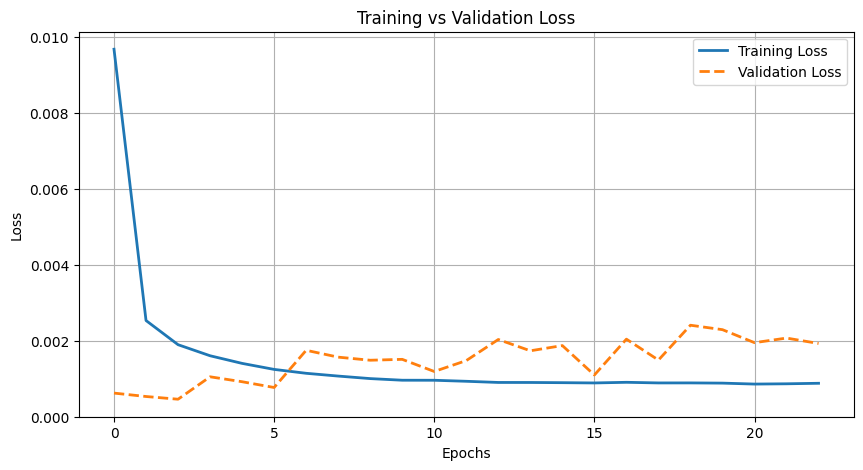

368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step
Mean Absolute Error (MAE): 1657.7204
Mean Squared Error (MSE): 5069935.0515
Root Mean Squared Error (RMSE): 2251.6516
Mean Absolute Percentage Error (MAPE): 2.30%
R-squared (R²): 0.9872


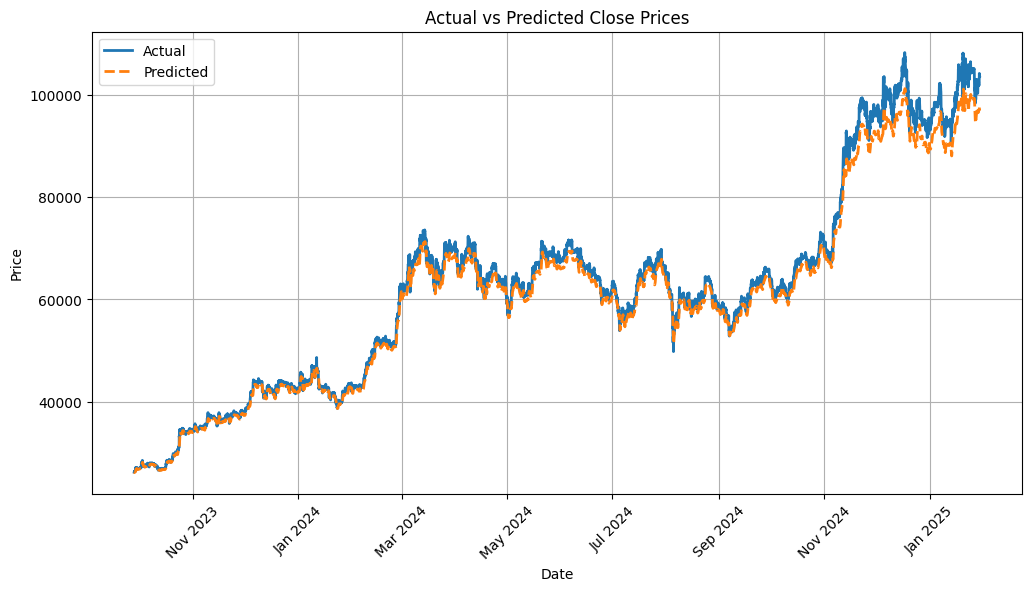

In [7]:
gru_model = Sequential()

# First GRU layer with dropout
gru_model.add(GRU(30, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
gru_model.add(Dropout(0.5))

# Fourth GRU layer (should NOT return sequences)
gru_model.add(GRU(30, return_sequences=False))  # << FIXED
gru_model.add(Dropout(0.5))

# Output layer: predicting only the close prices (1 feature)
gru_model.add(Dense(1))

# Define Learning Rate Decay
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0005,  
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True)

# Compile the model (fix optimizer issue)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
gru_model.compile(optimizer=optimizer, loss='mean_squared_error')

# Model Summary
gru_model.summary()

# Define Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

# Train the GRU model with Early Stopping
history = gru_model.fit(X_train, y_train, 
                        epochs=50,  # Increased epochs
                        batch_size=256, 
                        validation_data=(X_test, y_test), 
                        callbacks=[early_stopping],  
                        verbose=1)

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Use a separate scaler for close prices
close_scaler = MinMaxScaler()
data['close'] = close_scaler.fit_transform(data[['close']])

# Make predictions
predicted_gru = gru_model.predict(X_test)

# Inverse transform predictions
predicted_gru = close_scaler.inverse_transform(predicted_gru.reshape(-1, 1))
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

# Compute error metrics
mae = mean_absolute_error(y_test_actual, predicted_gru)
mse = mean_squared_error(y_test_actual, predicted_gru)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_gru) / y_test_actual)) * 100  
r2 = r2_score(y_test_actual, predicted_gru)

# Print results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

# Ensure the date index is in datetime format
date_index = pd.to_datetime(data.index[-len(y_test_actual):])

# Plot Actual vs Predicted Prices
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_gru, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Price')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Implementing LSTM

/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 15, 30)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30)             │         7,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,551 (45.12 KB)

 Trainable params: 11,551 (45.12 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0090 - val_loss: 0.0039
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0011 - val_loss: 4.3443e-04
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0011 - val_loss: 0.0017
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 9/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0010 - val_loss: 7.4329e-04
Epoch 10/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 9.9429e-04 - val_loss: 9.6219e-04
Epoch 11/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 9.9746e-04 - val_loss: 6.7411e-04
Epoch 12/50
184/1

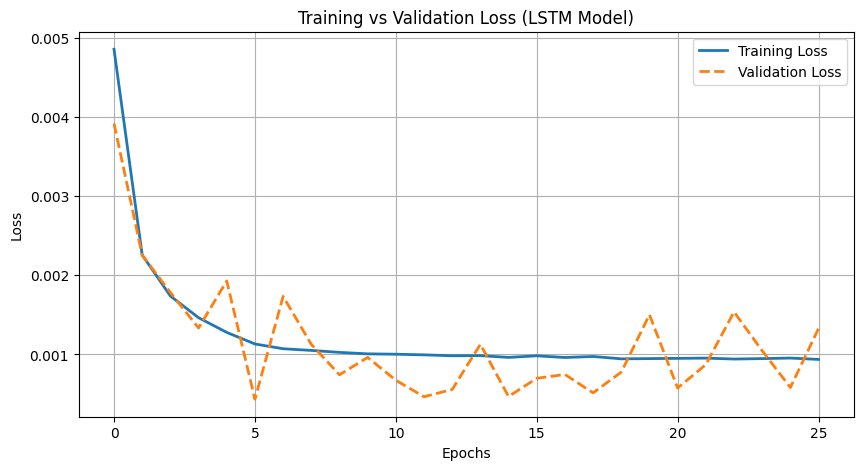

368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Model Error Statistics:
Mean Absolute Error (MAE): 0.0140
Mean Squared Error (MSE): 0.0004
Root Mean Squared Error (RMSE): 0.0208
Mean Absolute Percentage Error (MAPE): 2.07%
R-squared (R²): 0.9879


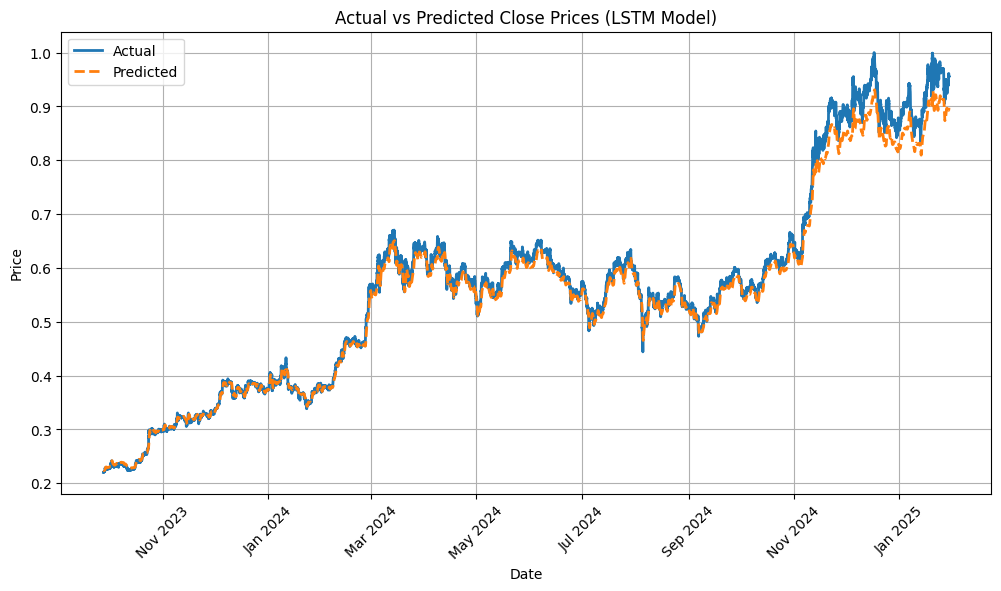

In [8]:
# LSTM Model (Fixed Version)
lstm_model = Sequential()

# First LSTM layer with dropout
lstm_model.add(LSTM(30, return_sequences=True, recurrent_dropout=0.2, input_shape=(X_train.shape[1], X_train.shape[2])))
lstm_model.add(Dropout(0.5))  # Increased dropout for consistency with GRU

# Fourth LSTM layer with dropout (return_sequences=False)
lstm_model.add(LSTM(30, return_sequences=False, recurrent_dropout=0.2))  # Fixed shape issue
lstm_model.add(Dropout(0.5))

# Output layer
lstm_model.add(Dense(1))

# Define Learning Rate Decay
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0005,  
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True)

# Compile the model (Fixed Optimizer Issue)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
lstm_model.compile(optimizer=optimizer, loss='mean_squared_error')

# Model Summary
lstm_model.summary()

# Define Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

# Train the LSTM model with Early Stopping
history = lstm_model.fit(X_train, y_train, 
                        epochs=50,  # Increased for better learning
                        batch_size=256,  # Increased for smoother validation loss
                        validation_data=(X_test, y_test), 
                        callbacks=[early_stopping],  
                        verbose=1)

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (LSTM Model)')
plt.legend()
plt.grid(True)
plt.show()

# Use a separate scaler for close prices
close_scaler = MinMaxScaler()
data['close'] = close_scaler.fit_transform(data[['close']])

# Make predictions
predicted_lstm = lstm_model.predict(X_test)

# Inverse transform predictions
predicted_lstm = close_scaler.inverse_transform(predicted_lstm.reshape(-1, 1))
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

# Compute error metrics
mae = mean_absolute_error(y_test_actual, predicted_lstm)
mse = mean_squared_error(y_test_actual, predicted_lstm)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_lstm) / y_test_actual)) * 100  
r2 = r2_score(y_test_actual, predicted_lstm)

# Print results
print(f"Model Error Statistics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

# Ensure the date index is in datetime format
date_index = pd.to_datetime(data.index[-len(y_test_actual):])

# Plot Actual vs Predicted Prices
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_lstm, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices (LSTM Model)')
plt.xlabel('Date')
plt.ylabel('Price')

# Format x-axis to show Month-Year
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Hybrid LSTM-GRU model

/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 15, 32)         │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,105 (43.38 KB)

 Trainable params: 11,105 (43.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0113 - val_loss: 0.0038
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0028 - val_loss: 0.0035
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0019 - val_loss: 9.8939e-04
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0013 - val_loss: 7.7058e-04
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0012 - val_loss: 4.3029e-04
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0011 - val_loss: 5.5194e-04
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0011 - val_loss: 6.4688e-04
Epoch 9/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0010 - val_loss: 9.1663e-04
Epoch 10/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.7585e-04 - val_loss: 7.2447e-04
Epoch 11/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.5671e-04 - val_loss: 6.2827e-04
E

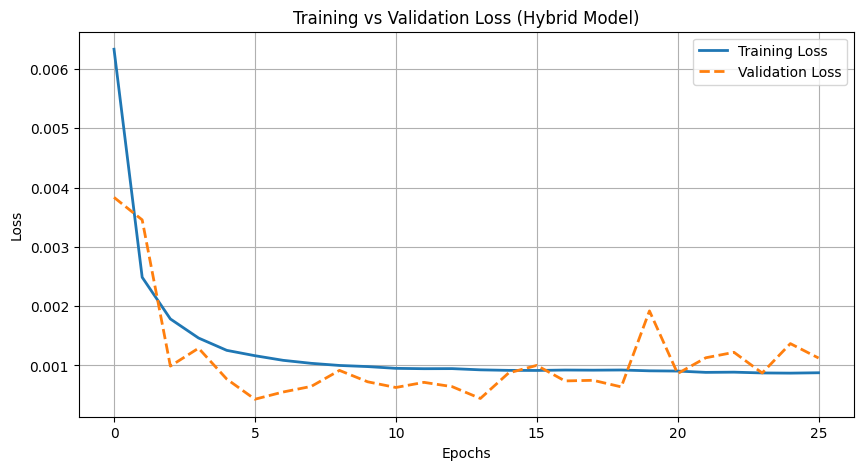

368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Hybrid Model Error Statistics:
Mean Absolute Error (MAE): 0.0146
Mean Squared Error (MSE): 0.0004
Root Mean Squared Error (RMSE): 0.0207
Mean Absolute Percentage Error (MAPE): 2.18%
R-squared (R²): 0.9880


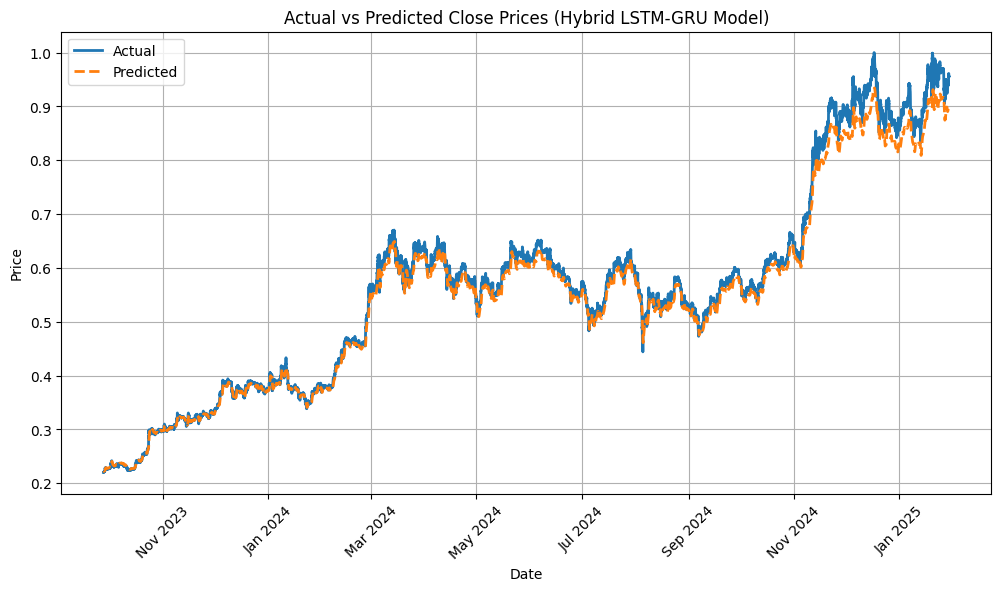

In [9]:
# Hybrid LSTM-GRU Model
hybrid_model = Sequential()

# First LSTM layer with recurrent dropout
hybrid_model.add(LSTM(32, return_sequences=True, recurrent_dropout=0.2, input_shape=(X_train.shape[1], X_train.shape[2])))
hybrid_model.add(Dropout(0.5))

# First GRU layer (return_sequences=False to avoid shape issues)
hybrid_model.add(GRU(32, return_sequences=False, recurrent_dropout=0.2))  
hybrid_model.add(Dropout(0.5))

# Output layer
hybrid_model.add(Dense(1))

# Define Learning Rate Decay
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0005,  # Start with a small learning rate
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True)

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
hybrid_model.compile(optimizer=optimizer, loss='mean_squared_error')

# Model Summary
hybrid_model.summary()

# Define Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

# Train the Hybrid Model
history_hybrid = hybrid_model.fit(X_train, y_train, 
                                  epochs=50,  
                                  batch_size=256,  # Increased batch size for stability
                                  validation_data=(X_test, y_test), 
                                  callbacks=[early_stopping],  
                                  verbose=1)

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history_hybrid.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_hybrid.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Hybrid Model)')
plt.legend()
plt.grid(True)
plt.show()

# Make predictions
predicted_hybrid = hybrid_model.predict(X_test)

# Use a separate scaler for close prices
close_scaler = MinMaxScaler()
data['close'] = close_scaler.fit_transform(data[['close']])

# Inverse transform the predicted and actual values using the correct scaler
predicted_hybrid = close_scaler.inverse_transform(predicted_hybrid.reshape(-1, 1))  # Fixed reshaping issue
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

# Evaluate model performance
mae = mean_absolute_error(y_test_actual, predicted_hybrid)
mse = mean_squared_error(y_test_actual, predicted_hybrid)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_hybrid) / y_test_actual)) * 100  
r2 = r2_score(y_test_actual, predicted_hybrid)

# Print results
print(f"Hybrid Model Error Statistics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

# Plot Actual vs Predicted Prices
date_index = pd.to_datetime(data.index[-len(y_test_actual):])
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_hybrid, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices (Hybrid LSTM-GRU Model)')
plt.xlabel('Date')
plt.ylabel('Price')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()